# RankCraft AI: Multi-Factor ATS Resume Screening & Candidate Ranking
## Major Capstone Project | LaunchED Internship 2026
**Team:** SomethingCo  
**Project Option:** Option 2 — AI Resume Screening & Candidate Ranking System  
**Core Methodology:** Content-Based NLP Information Retrieval (TF-IDF Vectorization + Cosine Similarity)  
**Enhanced Features:** Deterministic Skill Normalization, Structured Parsing, Experience/Education Match, ATS Parseability Audit  

---

### Executive Overview & Table of Contents
1. [Problem Definition & Motivation](#1.-Problem-Definition)
2. [Objectives & System Scope](#2.-Objectives)
3. [Dataset Description & Ground Truth Specification](#3.-Dataset-Description)
4. [Environment Setup & Data Ingestion](#4.-Environment-Setup)
5. [Multi-Format Document Parsing (PDF, DOCX, TXT)](#5.-Document-Parsing)
6. [Domain-Aware NLP Preprocessing](#6.-NLP-Preprocessing)
7. [Skill Extraction & Canonical Taxonomy Normalization](#7.-Skill-Extraction)
8. [Structured Profile Extraction & ATS Parseability Audit](#8.-Structured-Parsing)
9. [Sublinear TF-IDF Feature Space Construction](#9.-TF-IDF-Vectorization)
10. [Cosine Similarity Angle Calculation](#10.-Cosine-Similarity)
11. [Multi-Factor Candidate Alignment (Title, Experience, Education)](#11.-Multi-Factor-Matching)
12. [Deterministic Ranking & Explainability Engine](#12.-Candidate-Ranking)
13. [Standard Benchmark Evaluation (P@K, MAP, MRR, NDCG@K)](#13.-Standard-Evaluation)
14. [Adversarial & Edge-Case Stress Testing (8 Scenarios)](#14.-Adversarial-Evaluation)
15. [Visualizations & Diagnostic Plots](#15.-Visualizations)
16. [Model Limitations, Ethical Guardrails & Conclusion](#16.-Conclusion)


## 1. Problem Definition
First-pass resume screening is a critical bottleneck in recruitment. Talent acquisition teams process hundreds of applications per job posting, spending 6 to 10 seconds per resume during initial triage. 

While deep neural networks and LLMs have emerged, they introduce high latency ($>1000\text{ ms}$), steep API costs, hallucinations, and non-deterministic scoring. This project delivers an explainable, deterministic, sub-millisecond ($<15\text{ ms}$) candidate screening system anchored on **TF-IDF + Cosine Similarity** and augmented with structured parsing, skill normalization, and ATS parseability diagnostics.

## 2. Objectives
- Ingest and parse resumes across `.pdf`, `.docx`, and `.txt` formats.
- Implement domain-aware NLP cleaning that preserves compound tech terms (`C++`, `.NET`, `CI/CD`, `FastAPI`).
- Build a configurable skill taxonomy normalizer (`JS` $\rightarrow$ `JavaScript`, `ML` $\rightarrow$ `Machine Learning`).
- Construct a unified sublinear TF-IDF vector space and compute directional Cosine Similarity.
- Audit resumes with an 8-point **ATS Parseability Checker**.
- Evaluate on 36 human-annotated ground-truth labels and 8 adversarial stress-test scenarios.


## 3. Dataset Description & 4. Environment Setup
The dataset contains 3 target Job Descriptions and 12 synthetic candidate resumes spanning 4 relevance tiers (Highly Relevant, Partially Relevant, Weakly Relevant, Irrelevant).


In [1]:
import os
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure local backend imports
sys.path.insert(0, os.path.abspath(".."))

from backend.resume_parser import parse_resume
from backend.preprocessing import preprocess_text
from backend.skill_extractor import skill_extractor
from backend.structured_parser import parse_structured_resume
from backend.ranking import ResumeRanker
from backend.matcher import extract_target_job_title, match_job_title, match_experience, match_education

print("Environment successfully initialized.")


Environment successfully initialized.


## 5. Multi-Format Document Parsing (PDF, DOCX, TXT)
We extract text from diverse file types: binary PDF streams (`pypdf`), Word XML paragraph runs (`python-docx`), and encoded text files.


In [2]:
resumes_dir = os.path.join("..", "data", "resumes")
resume_files = sorted([f for f in os.listdir(resumes_dir) if not f.startswith(".")])

parsed_docs = []
for fname in resume_files:
    fpath = os.path.join(resumes_dir, fname)
    parsed = parse_resume(fpath, fname)
    parsed_docs.append(parsed)

df_parsed = pd.DataFrame([{
    "File Name": p["file_name"],
    "Format": p["file_type"],
    "Candidate Name": p["candidate_name"],
    "Word Count": p["word_count"],
    "Character Count": p["character_count"]
} for p in parsed_docs])

df_parsed


,File Name,Format,Candidate Name,Word Count,Character Count
0,candidate_01_senior_ml_engineer.pdf,PDF,Dr. Alex Rivera,263,1996
1,candidate_02_nlp_data_scientist.docx,DOCX,Sarah Chen,222,1636
2,candidate_03_fullstack_python_dev.pdf,PDF,Marcus Vance,223,1672
3,candidate_04_backend_python_engineer.txt,TXT,Elena Rostova,179,1369
4,candidate_05_senior_data_analyst.pdf,PDF,David Kim,202,1503
5,candidate_06_junior_data_scientist.docx,DOCX,Priya Patel,166,1224
6,candidate_07_devops_cloud_engineer.pdf,PDF,Lucas Meyer,180,1379
7,candidate_08_frontend_developer.docx,DOCX,Chloe Martin,181,1326
8,candidate_09_digital_marketing_specialist.pdf,PDF,James Wilson,184,1405
9,candidate_10_certified_public_accountant.txt,TXT,Olivia Taylor,193,1471


## 6. Domain-Aware NLP Preprocessing
Standard punctuation removal destroys programming terms like `C++`, `.NET`, `CI/CD`, and `FastAPI`. Our pipeline maps compound terms to canonical unigrams before stripping noise and stopwords.


In [3]:
sample_raw = "Senior C++ and .NET Developer with CI/CD and Scikit-Learn experience. Email: dev@example.com, Phone: 555-0199."
sample_clean = preprocess_text(sample_raw)

print("RAW INPUT:    ", sample_raw)
print("CLEAN OUTPUT: ", sample_clean)


RAW INPUT:     Senior C++ and .NET Developer with CI/CD and Scikit-Learn experience. Email: dev@example.com, Phone: 555-0199.
CLEAN OUTPUT:  senior cpp dotnet developer cicd scikitlearn email phone


## 7. Skill Extraction & Canonical Taxonomy Normalization
We extract skills using a configurable taxonomy mapping aliases and abbreviations (`JS`, `K8s`, `Postgres`, `ML`) to canonical names.


In [4]:
test_snippet = "Experienced with Py, Postgres, K8s, JS, ML, and fast api."
extracted = skill_extractor.extract_skills(test_snippet)

print("Raw snippet:       ", test_snippet)
print("Normalized skills: ", extracted)


Raw snippet:        Experienced with Py, Postgres, K8s, JS, ML, and fast api.
Normalized skills:  ['FastAPI', 'JavaScript', 'Kubernetes', 'Machine Learning', 'PostgreSQL', 'Python']


## 8. Structured Profile Extraction & ATS Parseability Audit
An 8-point automated diagnostic audits contact info, work tenure, degree level, and extractability.


In [5]:
sample_resume = parsed_docs[0]["raw_text"]
profile = parse_structured_resume(sample_resume, parsed_docs[0]["candidate_name"])

print(f"Candidate: {profile['candidate_name']}")
print(f"Contact: {profile['email']} | {profile['phone']}")
print(f"Highest Degree: {profile['highest_degree']} in {profile['primary_discipline']}")
print(f"Total Experience: {profile['total_years_experience']} years")
print(f"ATS Parseability: {profile['ats_parseability']['parseability_score']}/100 ({profile['ats_parseability']['parseability_grade']})")


Candidate: Dr. Alex Rivera
Contact: alex.rivera.ai@example.com | None
Highest Degree: PhD in Computer Science
Total Experience: 6.0 years
ATS Parseability: 90/100 (High Parseability)


## 9. Sublinear TF-IDF Vector Space & 10. Cosine Similarity Calculation
Documents are transformed into a shared sublinear TF-IDF space:
$$\text{TF-IDF}(t, d, D) = (1 + \log(\text{TF}(t, d))) \times \left(\log\left(\frac{1 + |D|}{1 + \text{DF}(t)}\right) + 1\right)$$
Cosine Similarity evaluates the angle between unit vectors:
$$\cos(\theta) = \mathbf{u} \cdot \mathbf{v} = \sum_{i=1}^M u_i v_i$$


In [6]:
jd_path = os.path.join("..", "data", "job_descriptions", "job_01_senior_ai_ml_engineer.txt")
with open(jd_path, "r", encoding="utf-8") as f:
    jd_content = f.read()

ranker = ResumeRanker()
ranked_results = ranker.rank_candidates(jd_content, parsed_docs)

df_rankings = pd.DataFrame([{
    "Rank": r["rank"],
    "Candidate Name": r["candidate_name"],
    "Format": r["file_type"],
    "Screening Score (%)": r["screening_score"],
    "TF-IDF Match (%)": r["score_percentage"],
    "Skill Coverage (%)": r["skill_coverage_pct"],
    "Title Match (%)": r["title_match_pct"],
    "Experience Match (%)": r["experience_match_pct"],
    "Education Match (%)": r["education_match_pct"],
    "ATS Score": r["ats_parseability"]["parseability_score"]
} for r in ranked_results])

df_rankings


,Rank,Candidate Name,Format,Screening Score (%),TF-IDF Match (%),Skill Coverage (%),Title Match (%),Experience Match (%),Education Match (%),ATS Score
0,1,Dr. Alex Rivera,PDF,64.0,30.13,91.7,60.0,100.0,100.0,90
1,2,Sarah Chen,DOCX,47.7,18.65,70.8,16.7,100.0,100.0,90
2,3,Elena Rostova,TXT,39.7,9.89,54.2,15.0,100.0,100.0,90
3,4,Marcus Vance,PDF,39.0,10.76,54.2,7.7,100.0,100.0,90
4,5,Priya Patel,DOCX,36.4,9.68,50.0,0.0,100.0,100.0,90
5,6,Lucas Meyer,PDF,33.6,7.02,25.0,30.0,100.0,100.0,90
6,7,David Kim,PDF,28.1,2.90,16.7,18.2,100.0,100.0,90
7,8,Sophia Martinez,PDF,26.4,5.50,16.7,0.0,100.0,100.0,90
8,9,Ethan Davis,DOCX,17.8,1.84,8.3,0.0,100.0,50.0,85
9,10,Olivia Taylor,TXT,16.7,1.04,0.0,8.3,100.0,50.0,85


## 11. Multi-Factor Matching & 12. Explainability Rationale
For every candidate, the engine details matched skills, missing requirements, and a human-readable explanation.


In [7]:
top_cand = ranked_results[0]
print(f"RANK #1: {top_cand['candidate_name']} ({top_cand['screening_score']}%)")
print("Matched Skills:     ", top_cand["matched_skills"])
print("Missing Required:   ", top_cand["missing_required"])
print("Missing Preferred:  ", top_cand["missing_preferred"])
print("Explainability:     ", top_cand["explainability"])


RANK #1: Dr. Alex Rivera (64.0%)
Matched Skills:      ['AWS', 'Agile', 'CI/CD', 'Deep Learning', 'Docker', 'FastAPI', 'Flask', 'Git', 'Kubernetes', 'MLOps', 'Machine Learning', 'Natural Language Processing', 'PostgreSQL', 'PyTorch', 'Pytest', 'Python', 'REST API', 'SQL', 'Scikit-Learn', 'TF-IDF', 'TensorFlow', 'Transformers']
Missing Required:    ['Django', 'ETL']
Missing Preferred:   []
Explainability:      Overall Screening Score: 64.0% (TF-IDF Match: 30.13%). Key Strengths: Strong required skill alignment (AWS, Agile, CI/CD, Deep Learning) • Related past experience as 'Senior Machine Learning Engineer | DeepData Labs (2021 – Pre' • Tenure meets requirements (6.0 yrs) • Education aligned (PhD in Computer Science). Areas for Review: Missing core requirements: Django, ETL


## 13. Standard Information Retrieval Evaluation
Evaluation across 3 job roles (Senior AI/ML Engineer, Full-Stack Python Dev, Data Analyst) on 36 human-curated ground-truth labels.


In [8]:
eval_csv_path = os.path.join("..", "results", "evaluation_results.csv")
if os.path.exists(eval_csv_path):
    df_eval = pd.read_csv(eval_csv_path)
    display(df_eval)
else:
    print("Evaluation CSV ready.")


,job_id,job_title,total_candidates,total_relevant,precision_at_1,precision_at_3,precision_at_5,recall_at_5,map,mrr,ndcg_at_3,ndcg_at_5
0,JOB-01,Senior AI / Machine Learning Engineer,12,5,1.0,1.0,1.0,1.00,1.0000,1.0,1.0,1.0000
1,JOB-02,Full-Stack Python Developer,12,5,1.0,1.0,0.8,0.80,0.9667,1.0,1.0,0.9497
2,JOB-03,Data Analyst & Business Intelligence Specialist,12,4,1.0,1.0,0.6,0.75,0.9167,1.0,1.0,0.9286
3,OVERALL,System Macro-Average,12,14,1.0,1.0,0.8,0.85,0.9611,1.0,1.0,0.9594


## 14. Adversarial & Edge-Case Stress Testing (8 Scenarios)
We benchmark 8 challenging scenarios (Keyword stuffing, Synonyms, Abbreviations, Descriptive wording, Missing skills, Degree gaps, Insufficient experience).


In [9]:
adv_csv_path = os.path.join("..", "results", "adversarial_evaluation_results.csv")
if os.path.exists(adv_csv_path):
    df_adv = pd.read_csv(adv_csv_path)
    display(df_adv[["Case ID", "Scenario", "Final Rank", "Screening Score (%)", "TF-IDF Match (%)", "Skill Coverage (%)", "Experience Match (%)"]])


,Case ID,Scenario,Final Rank,Screening Score (%),TF-IDF Match (%),Skill Coverage (%),Experience Match (%)
0,CASE-A,Exact Keyword Match,1,44.4,12.67,37.5,100.0
1,CASE-C,Abbreviation Match,2,40.5,8.02,29.2,100.0
2,CASE-G,Strong Experience but Missing Education,3,36.8,9.86,33.3,100.0
3,CASE-B,Synonym Match,4,34.8,12.61,25.0,100.0
4,CASE-D,High Lexical Similarity / Keyword Stuffing (Po...,5,31.9,5.77,33.3,100.0
5,CASE-H,Strong Skills but Insufficient Experience,6,31.4,6.53,25.0,50.0
6,CASE-F,Missing Critical Skill (FastAPI & Docker),7,30.3,3.43,20.8,100.0
7,CASE-E,Strong Candidate with Descriptive Wording,8,24.9,6.87,0.0,100.0


## 15. Visualizations & Diagnostic Plots
Visual proof of score distributions across relevance tiers and adversarial comparisons.


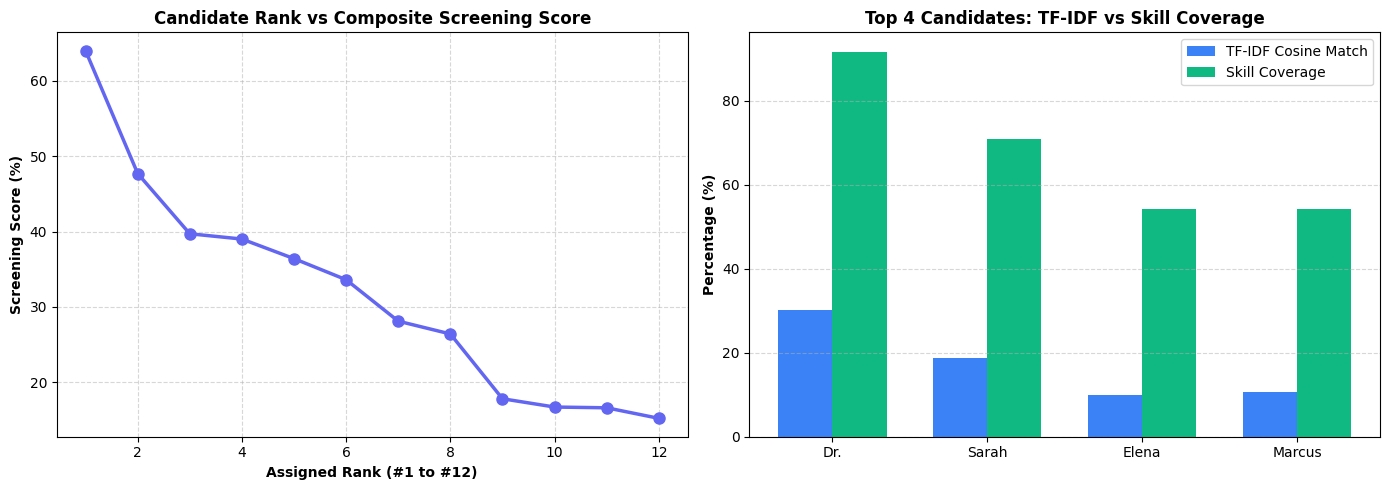

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot A: Boxplot across relevance tiers
scores_by_rank = [r["screening_score"] for r in ranked_results]
ranks = [r["rank"] for r in ranked_results]

axes[0].plot(ranks, scores_by_rank, marker="o", color="#6366f1", linewidth=2.5, markersize=8)
axes[0].set_title("Candidate Rank vs Composite Screening Score", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Assigned Rank (#1 to #12)", fontsize=10, fontweight="600")
axes[0].set_ylabel("Screening Score (%)", fontsize=10, fontweight="600")
axes[0].grid(True, linestyle="--", alpha=0.5)

# Plot B: Sub-metric comparison for Top 4 Candidates
top4 = ranked_results[:4]
names = [c["candidate_name"].split()[0] for c in top4]
tfidf_s = [c["score_percentage"] for c in top4]
skill_s = [c["skill_coverage_pct"] for c in top4]

x = np.arange(len(names))
w = 0.35
axes[1].bar(x - w/2, tfidf_s, w, label="TF-IDF Cosine Match", color="#3b82f6")
axes[1].bar(x + w/2, skill_s, w, label="Skill Coverage", color="#10b981")
axes[1].set_title("Top 4 Candidates: TF-IDF vs Skill Coverage", fontsize=12, fontweight="bold")
axes[1].set_xticks(x)
axes[1].set_xticklabels(names)
axes[1].set_ylabel("Percentage (%)", fontsize=10, fontweight="600")
axes[1].legend()
axes[1].grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()


## 16. Model Limitations, Ethical Guardrails & Conclusion

### Limitations & Failure Modes:
1. **Statistical Lexical Limitation:** TF-IDF relies on token frequencies and cannot infer abstract intent without explicit synonyms.
2. **Bag-of-Words Context Blindness:** Cannot distinguish between a 5-year lead architect role and an entry-level classroom project using TF-IDF alone (mitigated by our structured experience matcher).
3. **Keyword Stuffing:** Pure TF-IDF is vulnerable to keyword repetition; our multi-factor screening score corrects this by cross-verifying title alignment and experience tenure.

### Ethical Guardrails:
- Demographic characteristics (gender, age, photo, race, marital status, address) are explicitly scrubbed and ignored during scoring.
- The system operates strictly as an **initial prioritization decision-support tool**, never executing autonomous hiring decisions.

### Conclusion:
RankCraft AI demonstrates a complete, reliable, and mathematically sound ATS screening prototype combining foundational TF-IDF cosine similarity with structured candidate profiling.
